# Results from SSNAP coeffs DEAP runs

Visually inspect the admissions coefficients from the genetic algorithm results. Calculate r-squared values to decide which coefficients are the best.

__Inputs:__

+ Best individuals for each generation of each run of the genetic algorithm.
+ MSOA-level admissions and population data for calculating admissions from resulting coefficients.
+ SSNAP-derived coefficients for converting scale factors into probability coefficients.

__Results:__

+ Calculated r-squared values for the fits of calculated to observed admission numbers.
+ Images of the resulting coefficients.

__Method:__

For each run of the genetic algorithm, keep a copy of the best set of coefficients in the final generation.

Calculate the r-squared values associated with each set of coefficients.

Plot the coefficients to gauge the range of values.

Pick out the "best" values, where the r-squared value rounds to the same as the best r-squared value.

## Code setup

In [1]:
import os
import polars as pl
import numpy as np
import matplotlib.pyplot as plt

## Load data

List of directories to load from:

In [2]:
results_dirs = sorted([d for d in os.listdir(os.path.join('genetic_algorithms', 'outputs')) if d.startswith('randomseed')])

Load all dataframes and store the final generation's best individual:

In [3]:
dfs_to_merge = []
results_dirs_to_merge = []

for results_dir in results_dirs:
    path_to_results = os.path.join('genetic_algorithms', 'outputs', results_dir, 'best_inds_by_gen.csv')
    try:
        df = pl.read_csv(path_to_results)
        final_gen_best = df.filter(df['fitness'] == df['fitness'].min())[-1]
        dfs_to_merge.append(final_gen_best)
        results_dirs_to_merge.append(results_dir)
    except FileNotFoundError:
        pass

Combine all dataframes:

In [4]:
df_best_gens = pl.concat(dfs_to_merge)
# Add a column to label results directory:
df_best_gens = df_best_gens.with_columns(pl.Series('dir', results_dirs_to_merge))
# Move label to first column:
df_best_gens = df_best_gens.drop('dir').insert_column(0, df_best_gens.get_column('dir'))

In [5]:
df_best_gens.sort('fitness')

dir,# gen,age_less65_q00,age_65_q00,age_70_q00,age_75_q00,age_over80_q00,age_less65_q02,age_65_q02,age_70_q02,age_75_q02,age_over80_q02,age_less65_q04,age_65_q04,age_70_q04,age_75_q04,age_over80_q04,age_less65_q06,age_65_q06,age_70_q06,age_75_q06,age_over80_q06,age_less65_q08,age_65_q08,age_70_q08,age_75_q08,age_over80_q08,fitness
str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
"""randomseed49""",35.0,1.3,1.2,1.2,1.3,1.211,1.0,1.007,1.1,1.052,1.178,0.941,1.0,0.975,1.0,0.948,0.881,1.0,0.975,0.9,0.9,0.875,0.9,0.827,0.769,0.9,237.742
"""randomseed55""",42.0,1.222,1.2,1.2,1.2,1.24,1.115,1.087,1.088,1.1,1.096,0.955,1.0,1.0,1.0,1.0,0.9,0.933,0.9,0.9,0.9,0.8,0.9,0.89,0.795,0.897,237.821
"""randomseed73""",48.0,1.3,1.3,1.218,1.2,1.2,1.0,1.111,1.1,1.106,1.12,0.992,0.971,1.0,0.95,1.0,0.897,0.971,0.973,0.9,0.9,0.8,0.803,0.8,0.83,0.9,237.915
"""randomseed27""",39.0,1.241,1.3,1.3,1.396,1.16,1.0,1.186,1.118,1.075,1.16,0.961,0.976,1.0,0.906,1.014,0.9,0.9,0.9,0.906,0.9,0.9,0.8,0.8,0.768,0.887,237.986
"""randomseed26""",20.0,1.3,1.383,1.206,1.3,1.2,1.0,0.984,1.074,1.0,1.194,1.0,0.984,1.016,1.0,0.942,0.9,0.9,0.896,0.9,0.9,0.8,0.9,0.884,0.808,0.9,238.002
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""randomseed81""",26.0,1.216,1.2,1.2,1.2,1.3,1.073,1.11,1.107,1.1,1.069,1.0,1.0,1.039,1.0,1.0,0.9,1.0,0.969,0.9,0.9,0.8,0.806,0.788,0.785,0.874,239.942
"""randomseed86""",39.0,1.18,1.285,1.129,1.2,1.367,1.1,1.1,1.1,1.1,1.1,0.995,0.959,1.0,1.0,0.969,0.884,0.901,0.948,0.9,0.942,0.827,0.9,0.9,0.8,0.806,239.985
"""randomseed12""",25.0,1.239,1.327,1.2,1.183,1.3,1.0,1.006,1.09,1.1,1.168,0.985,1.0,1.0,1.0,1.0,0.907,1.0,0.982,0.9,0.865,0.887,0.798,0.8,0.8,0.859,240.334


In [6]:
df_best_gens_scales = df_best_gens

## Load admissions data

In [7]:
path_to_msoa_stats = os.path.join('data', 'msoa_cleaned.csv')

df_stats = pl.read_csv(path_to_msoa_stats)

In [8]:
df_stats.head()

MSOA,admissions,IMD2019Score,All persons,country,good_health,fair health,bad health,prop_good_health,prop_fair health,prop_bad health,MSOA11CD,age_65_proportion,age_70_proportion,age_75_proportion,age_less65_proportion,age_over80_proportion,total_health,age_less65,age_65,age_70,age_75,age_over80,depriv_quantile_min,depriv_quantile_max
str,f64,f64,i64,str,i64,i64,i64,f64,f64,f64,str,f64,f64,f64,f64,f64,i64,f64,f64,f64,f64,f64,f64,f64
"""Adur 001""",14.333333,16.924833,8815,"""E""",6799,1251,474,0.79763,0.146762,0.055608,"""E02006534""",0.0559,0.0528,0.0422,0.7872,0.062,8524,6939.168,492.7585,465.432,371.993,546.53,0.4,0.6
"""Adur 002""",7.333333,6.4704,7263,"""E""",5537,838,259,0.83464,0.126319,0.039041,"""E02006535""",0.0578,0.0774,0.0492,0.7467,0.0692,6634,5423.2821,419.8014,562.1562,357.3396,502.5996,0.8,1.0
"""Adur 003""",9.333333,13.7334,7354,"""E""",5820,969,311,0.819718,0.136479,0.043803,"""E02006536""",0.0609,0.0582,0.0421,0.7729,0.0661,7100,5683.9066,447.8586,428.0028,309.6034,486.0994,0.6,0.8
"""Adur 004""",21.0,26.199857,10582,"""E""",7872,1546,709,0.777328,0.152661,0.070011,"""E02006537""",0.0465,0.0438,0.0367,0.8091,0.0638,10127,8561.8962,492.063,463.4916,388.3594,675.1316,0.2,0.4
"""Adur 005""",13.666667,11.7948,9059,"""E""",7106,1081,339,0.833451,0.126789,0.039761,"""E02006538""",0.0597,0.067,0.0425,0.7643,0.0662,8526,6923.7937,540.8223,606.953,385.0075,599.7058,0.6,0.8


Pick out column names for the health and age proportions:

In [9]:
health_numbers = ['good_health', 'fair health', 'bad health']
props_health = ['prop_good_health', 'prop_fair health', 'prop_bad health']
props_age = [
    'age_less65_proportion', 'age_65_proportion', 'age_70_proportion',
    'age_75_proportion', 'age_over80_proportion'
]
age_numbers = [p.replace('_proportion', '') for p in props_age]

In [10]:
qmin_list = sorted(df_stats['depriv_quantile_min'].unique())

In [11]:
# Names of coeffs:
coeff_names = [f'{a}_q{str(round(q, 1)).replace(".", "")}' for q in qmin_list for a in age_numbers]

coeff_names

['age_less65_q00',
 'age_65_q00',
 'age_70_q00',
 'age_75_q00',
 'age_over80_q00',
 'age_less65_q02',
 'age_65_q02',
 'age_70_q02',
 'age_75_q02',
 'age_over80_q02',
 'age_less65_q04',
 'age_65_q04',
 'age_70_q04',
 'age_75_q04',
 'age_over80_q04',
 'age_less65_q06',
 'age_65_q06',
 'age_70_q06',
 'age_75_q06',
 'age_over80_q06',
 'age_less65_q08',
 'age_65_q08',
 'age_70_q08',
 'age_75_q08',
 'age_over80_q08']

Admissions data:

In [12]:
admissions_lists = []
x_lists = []

for qmin in qmin_list:
    df_stats_here = df_stats.filter(df_stats['depriv_quantile_min'] == qmin)
    # MSOA data in the same order as those coefficients:
    x_lists_here = [df_stats_here[a] for a in age_numbers]
    admissions_here = df_stats_here['admissions'].to_numpy().tolist()
    # Store:
    admissions_lists.append(admissions_here)
    x_lists.append(x_lists_here)

Starting SSNAP coefficients:

In [13]:
df_pop_admissions = pl.read_csv(os.path.join('outputs', 'ssnap_coeffs.csv'))

In [14]:
df_pop_admissions

Age Groups,population,prop_of_all_pop,count,prop_of_all_admissions,admissions_annual,admissions_annual_boost,prob_stroke_given_age
str,i64,f64,i64,f64,f64,f64,f64
"""Under 65""",45933245,0.816055,38827,0.231449,12942.33333,18737.66819,0.000408
"""65-69""",2796740,0.049687,15324,0.091347,5108.0,7395.26689,0.002644
"""70-74""",2779326,0.049378,21508,0.12821,7169.33333,10379.62674,0.003735
"""75-79""",1940686,0.034478,24150,0.143959,8050.0,11654.63948,0.006005
"""80 and over""",2836964,0.050402,67947,0.405035,22649.0,32790.7987,0.011558


Pick out SSNAP coefficients:

In [15]:
coeffs_ssnap = df_pop_admissions['prob_stroke_given_age'].to_numpy()

coeffs_ssnap

array([0.000408, 0.002644, 0.003735, 0.006005, 0.011558])

In [16]:
labels = ['less65', '65', '70', '75', 'over80']

# coeffs_ssnap_dict = dict(zip(df_pop_admissions['Age Groups'].to_numpy(), df_pop_admissions['prob_stroke_given_age'].to_numpy()))
coeffs_ssnap_dict = dict(zip(labels, df_pop_admissions['prob_stroke_given_age'].to_numpy()))

coeffs_ssnap_dict

{'less65': 0.000408,
 '65': 0.002644,
 '70': 0.003735,
 '75': 0.006005,
 'over80': 0.011558}

## Convert best scales to coeffs

In [17]:
for coeff in coeff_names:
    key = coeff.split('_')[1]
    new_data = df_best_gens[coeff] * coeffs_ssnap_dict[key]
    
    df_best_gens = df_best_gens.with_columns(pl.Series(coeff, new_data))

Round results:

In [18]:
labels = ['less65', '65', '70', '75', 'over80']
# round_dict = dict(zip(labels, [5, 4, 4, 4, 4]))
round_dict = dict(zip(labels, [4, 3, 3, 3, 3]))

for coeff in coeff_names:
    key = coeff.split('_')[1]
    new_data = np.round(df_best_gens[coeff], round_dict[key])
    
    df_best_gens = df_best_gens.with_columns(pl.Series(coeff, new_data))

In [19]:
df_best_gens

dir,# gen,age_less65_q00,age_65_q00,age_70_q00,age_75_q00,age_over80_q00,age_less65_q02,age_65_q02,age_70_q02,age_75_q02,age_over80_q02,age_less65_q04,age_65_q04,age_70_q04,age_75_q04,age_over80_q04,age_less65_q06,age_65_q06,age_70_q06,age_75_q06,age_over80_q06,age_less65_q08,age_65_q08,age_70_q08,age_75_q08,age_over80_q08,fitness
str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
"""randomseed00""",33.0,0.0005,0.003,0.005,0.007,0.014,0.0004,0.003,0.004,0.006,0.013,0.0004,0.003,0.004,0.006,0.012,0.0004,0.002,0.004,0.006,0.011,0.0003,0.002,0.003,0.005,0.01,238.372
"""randomseed01""",33.0,0.0004,0.003,0.005,0.008,0.014,0.0004,0.003,0.004,0.006,0.013,0.0004,0.003,0.004,0.006,0.012,0.0004,0.002,0.003,0.005,0.01,0.0003,0.002,0.003,0.005,0.01,238.507
"""randomseed02""",43.0,0.0005,0.003,0.004,0.007,0.014,0.0004,0.003,0.004,0.007,0.013,0.0004,0.003,0.004,0.006,0.012,0.0004,0.003,0.003,0.005,0.01,0.0003,0.002,0.003,0.005,0.01,238.037
"""randomseed03""",28.0,0.0005,0.003,0.005,0.007,0.015,0.0004,0.003,0.004,0.007,0.013,0.0004,0.003,0.004,0.006,0.011,0.0004,0.002,0.003,0.006,0.01,0.0003,0.002,0.003,0.004,0.01,239.49
"""randomseed04""",39.0,0.0005,0.003,0.005,0.007,0.015,0.0004,0.003,0.004,0.006,0.013,0.0004,0.003,0.004,0.006,0.011,0.0004,0.002,0.003,0.005,0.011,0.0003,0.002,0.003,0.005,0.01,238.453
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""randomseed95""",35.0,0.0005,0.003,0.005,0.007,0.014,0.0005,0.003,0.004,0.006,0.013,0.0004,0.003,0.004,0.006,0.012,0.0004,0.002,0.003,0.006,0.01,0.0003,0.002,0.003,0.005,0.01,238.173
"""randomseed96""",28.0,0.0005,0.003,0.005,0.009,0.014,0.0004,0.003,0.004,0.006,0.013,0.0004,0.003,0.004,0.006,0.011,0.0004,0.002,0.003,0.006,0.01,0.0004,0.002,0.003,0.005,0.01,239.047
"""randomseed97""",46.0,0.0005,0.003,0.005,0.007,0.015,0.0004,0.003,0.004,0.007,0.013,0.0004,0.003,0.004,0.006,0.012,0.0004,0.003,0.003,0.005,0.01,0.0003,0.002,0.003,0.005,0.01,238.515


## Calculate r-squared

In [20]:
def predict_admissions(x_lists, coeffs):
    """
    x_lists: np.array.
    coeffs: np.array.
    
    Have to have same number of coeffs as x_lists.
    """
    # Predicted admissions:
    # yhat = (x_lists * coeffs.reshape(len(coeffs), 1)).sum(axis=0)
    yhat = sum(
        [x_lists[i] * coeffs[i] for i in range(len(coeffs))]
    )
    return yhat.to_numpy().tolist()

In [21]:
def calculate_rsquared(y, yhat):
    """This gives the same results as the sklearn built-in."""
    y = np.array(y)
    yhat = np.array(yhat)
    y_mean = np.mean(y)#.mean()
    ss_res = np.sum(((yhat - y)**2.0))#.sum()
    ss_tot = np.sum(((y - y_mean)**2.0))#.sum()
    if ss_tot != 0.0:
        rsq = 1.0 - ss_res / ss_tot
    else:
        rsq = np.NaN
    return rsq

In [22]:
def calculate_many_rsquared(coeffs, x_lists, coeffs_ssnap, admissions_lists):
    list_r2 = []
    predictions_lists = []
    for i in range(5):
        # Population numbers for areas in this quantile:
        x_lists_here = x_lists[i]
        # Separate prediction for each deprivation quantile:
        c = np.array(coeffs[(i*5):(i*5)+5]) #* np.array(coeffs_ssnap)
        yhat = predict_admissions(x_lists_here, c)
        predictions_lists.append(yhat)
        observed_here = admissions_lists[i]
        r2 = calculate_rsquared(observed_here, yhat)
        list_r2.append(r2)

    # Combine lists:
    observed_all = sum(admissions_lists, [])
    predicted_all = sum(predictions_lists, [])
    # Calculate r-squared:
    r2 = calculate_rsquared(observed_all, predicted_all)
    list_r2.append(r2)
    return list_r2

Calculate r-squared values and store in dictionaries:

In [23]:
dict_r2 = {}
dict_r2_qs = [{}, {}, {}, {}, {}]

for results_dir in results_dirs_to_merge:
    # Pick out coeffs:
    coeffs = df_best_gens.filter(df_best_gens['dir'] == results_dir)[coeff_names].to_numpy().flatten()

    list_r2 = calculate_many_rsquared(coeffs, x_lists, coeffs_ssnap, admissions_lists)
    for i in range(len(dict_r2_qs)):
        dict_r2_qs[i][results_dir] = list_r2[i]
    dict_r2[results_dir] = list_r2[-1]

Convert dictionaries to dataframes:

In [24]:
df_r2 = pl.from_dict(dict_r2).transpose(include_header=True).rename({'column': 'dir', 'column_0': 'r2_all'})
df_r2_q00 = pl.from_dict(dict_r2_qs[0]).transpose(include_header=True).rename({'column': 'dir', 'column_0': 'r2_q00'})
df_r2_q02 = pl.from_dict(dict_r2_qs[1]).transpose(include_header=True).rename({'column': 'dir', 'column_0': 'r2_q02'})
df_r2_q04 = pl.from_dict(dict_r2_qs[2]).transpose(include_header=True).rename({'column': 'dir', 'column_0': 'r2_q04'})
df_r2_q06 = pl.from_dict(dict_r2_qs[3]).transpose(include_header=True).rename({'column': 'dir', 'column_0': 'r2_q06'})
df_r2_q08 = pl.from_dict(dict_r2_qs[4]).transpose(include_header=True).rename({'column': 'dir', 'column_0': 'r2_q08'})

Combine r-squared dataframes with the main results dataframe:

In [25]:
for df in [df_r2, df_r2_q00, df_r2_q02, df_r2_q04, df_r2_q06, df_r2_q08]:
    df_best_gens = df_best_gens.join(df, on='dir')

Check results:

In [26]:
df_best_gens.sort('r2_all', descending=True)

dir,# gen,age_less65_q00,age_65_q00,age_70_q00,age_75_q00,age_over80_q00,age_less65_q02,age_65_q02,age_70_q02,age_75_q02,age_over80_q02,age_less65_q04,age_65_q04,age_70_q04,age_75_q04,age_over80_q04,age_less65_q06,age_65_q06,age_70_q06,age_75_q06,age_over80_q06,age_less65_q08,age_65_q08,age_70_q08,age_75_q08,age_over80_q08,fitness,r2_all,r2_q00,r2_q02,r2_q04,r2_q06,r2_q08
str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
"""randomseed24""",23.0,0.0005,0.004,0.005,0.007,0.014,0.0004,0.003,0.004,0.007,0.013,0.0004,0.002,0.004,0.006,0.012,0.0004,0.002,0.003,0.005,0.011,0.0003,0.002,0.003,0.005,0.01,238.421,0.593483,0.509119,0.583466,0.634746,0.612783,0.606993
"""randomseed08""",36.0,0.0005,0.003,0.005,0.007,0.015,0.0004,0.003,0.004,0.007,0.013,0.0004,0.003,0.004,0.006,0.011,0.0004,0.003,0.004,0.005,0.01,0.0003,0.002,0.003,0.005,0.01,238.56,0.591779,0.508469,0.583466,0.631482,0.608507,0.606993
"""randomseed04""",39.0,0.0005,0.003,0.005,0.007,0.015,0.0004,0.003,0.004,0.006,0.013,0.0004,0.003,0.004,0.006,0.011,0.0004,0.002,0.003,0.005,0.011,0.0003,0.002,0.003,0.005,0.01,238.453,0.591769,0.508469,0.579147,0.631482,0.612783,0.606993
"""randomseed17""",20.0,0.0005,0.003,0.005,0.007,0.015,0.0004,0.003,0.004,0.007,0.013,0.0004,0.003,0.004,0.006,0.011,0.0004,0.003,0.003,0.005,0.01,0.0003,0.002,0.003,0.005,0.01,239.924,0.591412,0.508469,0.583466,0.631482,0.606683,0.606993
"""randomseed19""",34.0,0.0005,0.003,0.005,0.007,0.015,0.0004,0.003,0.004,0.007,0.013,0.0004,0.003,0.004,0.006,0.011,0.0004,0.003,0.003,0.005,0.01,0.0003,0.002,0.003,0.005,0.01,239.009,0.591412,0.508469,0.583466,0.631482,0.606683,0.606993
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""randomseed65""",19.0,0.0005,0.004,0.005,0.008,0.014,0.0005,0.003,0.004,0.007,0.013,0.0004,0.003,0.004,0.006,0.012,0.0004,0.002,0.003,0.005,0.01,0.0003,0.002,0.003,0.005,0.01,239.802,0.57744,0.505377,0.556782,0.616005,0.583824,0.606993
"""randomseed05""",19.0,0.0005,0.003,0.004,0.007,0.015,0.0004,0.003,0.004,0.006,0.012,0.0004,0.003,0.004,0.006,0.012,0.0004,0.002,0.003,0.005,0.01,0.0003,0.002,0.003,0.005,0.01,238.254,0.577355,0.502059,0.559312,0.616005,0.583824,0.606993
"""randomseed89""",25.0,0.0005,0.003,0.004,0.007,0.014,0.0005,0.003,0.004,0.006,0.013,0.0004,0.003,0.004,0.006,0.012,0.0004,0.002,0.003,0.005,0.01,0.0003,0.002,0.003,0.005,0.01,238.894,0.576409,0.485431,0.569427,0.616005,0.583824,0.606993


In [27]:
r2_best = df_best_gens['r2_all'].max()

r2_best

0.5934830999955307

In [28]:
df_best_gens_to_save = df_best_gens_scales.join(df_best_gens[['dir'] + [c for c in df_best_gens.columns if c.startswith('r2')]], on='dir')

In [29]:
df_best_gens_to_save.write_csv(os.path.join('outputs', 'best_inds_deap.csv'))

## Check best individuals

Plot to gauge the range of values:

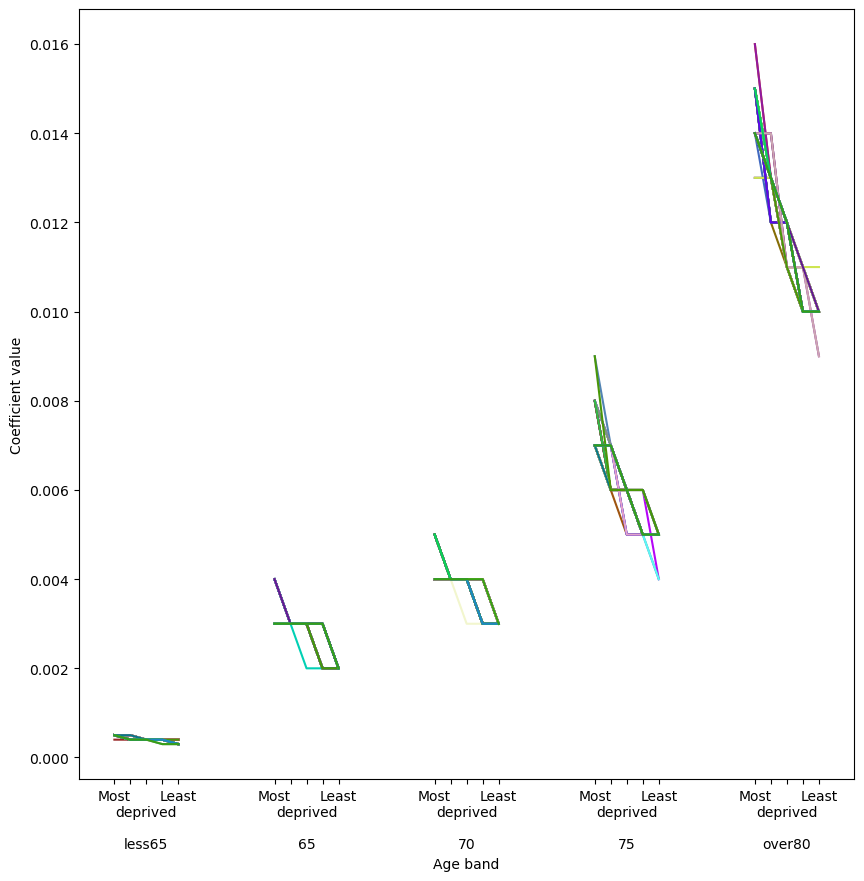

In [30]:
age_bands = ['less65', '65', '70', '75', 'over80']
x_offsets = np.arange(-0.2, 0.3, 0.1)
xticks_minor = np.concatenate([x_offsets + a for a in range(len(age_bands))])

qmin_labels = np.concatenate([['Most', '', '' + '\ndeprived\n\n' + age_band, '', 'Least'] for age_band in age_bands])

np.random.seed(42)
fig, ax = plt.subplots(figsize=(10, 10))

for results_dir in results_dirs_to_merge:
    # Pick out coeffs:
    coeffs = df_best_gens.filter(df_best_gens['dir'] == results_dir)[coeff_names].to_numpy().flatten()
    # if results_dir in df_best_gens_topr2['dir']:
    colour = np.random.rand(3,)
    zorder = 5
    alpha = 1.0
    # else:
    #     colour = 'silver'
    #     zorder = 4
    #     alpha = 0.4
    # g = gen_attr(df_coeffs_init)

    offset = -0.2
    for c in range(5):
        # xs = np.arange(5) + offset
        # ys = g[c*5:(c*5)+5]
        xs = np.arange(-0.2, 0.3, 0.1) + c
        
        ys = np.array(coeffs)[np.arange(0, 25, 5) + c]# * np.array([coeffs_ssnap[c]] * 5)
        ax.plot(xs, ys, color=colour, zorder=zorder, alpha=alpha, label=(results_dir if c==0 else None))
        offset += 0.1


ax.set_xticks(xticks_minor)
ax.set_xticklabels(qmin_labels)
ax.set_xlabel('Age band')
ax.set_ylabel('Coefficient value')

# Save:
plt.savefig('./images/scatter_coeffs_from_deap_round1sf.png', bbox_inches='tight')
plt.show()

Check mean, std, min, max values:

In [31]:
pl.concat([
    df_best_gens.mean().select(pl.col(float).round(5)),
    df_best_gens.std().select(pl.col(float).round(5)),
    df_best_gens.min().select(pl.col(float).round(5)),
    df_best_gens.max().select(pl.col(float).round(5)),
])

# gen,age_less65_q00,age_65_q00,age_70_q00,age_75_q00,age_over80_q00,age_less65_q02,age_65_q02,age_70_q02,age_75_q02,age_over80_q02,age_less65_q04,age_65_q04,age_70_q04,age_75_q04,age_over80_q04,age_less65_q06,age_65_q06,age_70_q06,age_75_q06,age_over80_q06,age_less65_q08,age_65_q08,age_70_q08,age_75_q08,age_over80_q08,fitness,r2_all,r2_q00,r2_q02,r2_q04,r2_q06,r2_q08
f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
29.06,0.0005,0.00315,0.00449,0.00721,0.01432,0.00042,0.003,0.004,0.00665,0.01292,0.0004,0.00299,0.00399,0.00595,0.01176,0.0004,0.00233,0.0032,0.00515,0.0103,0.00032,0.002,0.003,0.00497,0.00999,238.92956,0.58485,0.49949,0.57816,0.62063,0.60044,0.60589
10.49947,0.00001,0.00036,0.0005,0.00046,0.00057,0.00004,0.0,0.0,0.00048,0.00037,0.0,0.0001,0.0001,0.00022,0.00043,0.00001,0.00047,0.0004,0.00036,0.00046,0.00004,0.0,0.0,0.00017,0.00017,0.58972,0.00393,0.00924,0.00807,0.00712,0.01229,0.00786
11.0,0.0004,0.003,0.004,0.007,0.013,0.0004,0.003,0.004,0.006,0.012,0.0004,0.002,0.003,0.005,0.011,0.0003,0.002,0.003,0.005,0.01,0.0003,0.002,0.003,0.004,0.009,237.742,0.57386,0.47158,0.55678,0.61601,0.58359,0.55974
70.0,0.0005,0.004,0.005,0.009,0.016,0.0005,0.003,0.004,0.007,0.014,0.0004,0.003,0.004,0.006,0.012,0.0004,0.003,0.004,0.006,0.011,0.0004,0.002,0.003,0.005,0.011,240.581,0.59348,0.50912,0.58385,0.63475,0.61601,0.62481


In [32]:
pl.concat([
    df_best_gens.select(pl.col(float).round(5)).mean(),
    df_best_gens.select(pl.col(float).round(5)).std(),
    df_best_gens.select(pl.col(float).round(5)).min(),
    df_best_gens.select(pl.col(float).round(5)).max(),
])

# gen,age_less65_q00,age_65_q00,age_70_q00,age_75_q00,age_over80_q00,age_less65_q02,age_65_q02,age_70_q02,age_75_q02,age_over80_q02,age_less65_q04,age_65_q04,age_70_q04,age_75_q04,age_over80_q04,age_less65_q06,age_65_q06,age_70_q06,age_75_q06,age_over80_q06,age_less65_q08,age_65_q08,age_70_q08,age_75_q08,age_over80_q08,fitness,r2_all,r2_q00,r2_q02,r2_q04,r2_q06,r2_q08
f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
29.06,0.000499,0.00315,0.00449,0.00721,0.01432,0.000416,0.003,0.004,0.00665,0.01292,0.0004,0.00299,0.00399,0.00595,0.01176,0.000398,0.00233,0.0032,0.00515,0.0103,0.000317,0.002,0.003,0.00497,0.00999,238.92956,0.5848513,0.499495,0.578165,0.620638,0.600437,0.605891
10.499466,0.00001,0.000359,0.000502,0.000456,0.000566,0.000037,0.0,0.0,0.000479,0.000367,5.4483e-20,0.0001,0.0001,0.000219,0.000429,0.000014,0.000473,0.000402,0.000359,0.000461,0.000038,0.0,0.0,0.000171,0.000174,0.589719,0.003926,0.009242,0.008071,0.007115,0.012296,0.007862
11.0,0.0004,0.003,0.004,0.007,0.013,0.0004,0.003,0.004,0.006,0.012,0.0004,0.002,0.003,0.005,0.011,0.0003,0.002,0.003,0.005,0.01,0.0003,0.002,0.003,0.004,0.009,237.742,0.57386,0.47158,0.55678,0.61601,0.58359,0.55974
70.0,0.0005,0.004,0.005,0.009,0.016,0.0005,0.003,0.004,0.007,0.014,0.0004,0.003,0.004,0.006,0.012,0.0004,0.003,0.004,0.006,0.011,0.0004,0.002,0.003,0.005,0.011,240.581,0.59348,0.50912,0.58385,0.63475,0.61601,0.62481


In [33]:
# df_best_gens.sort('fitness')
df_best_gens.sort('fitness').select(pl.col(float).round(5))

# gen,age_less65_q00,age_65_q00,age_70_q00,age_75_q00,age_over80_q00,age_less65_q02,age_65_q02,age_70_q02,age_75_q02,age_over80_q02,age_less65_q04,age_65_q04,age_70_q04,age_75_q04,age_over80_q04,age_less65_q06,age_65_q06,age_70_q06,age_75_q06,age_over80_q06,age_less65_q08,age_65_q08,age_70_q08,age_75_q08,age_over80_q08,fitness,r2_all,r2_q00,r2_q02,r2_q04,r2_q06,r2_q08
f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
35.0,0.0005,0.003,0.004,0.008,0.014,0.0004,0.003,0.004,0.006,0.014,0.0004,0.003,0.004,0.006,0.011,0.0004,0.003,0.004,0.005,0.01,0.0004,0.002,0.003,0.005,0.01,237.742,0.59021,0.49775,0.58385,0.63148,0.60851,0.60841
42.0,0.0005,0.003,0.004,0.007,0.014,0.0005,0.003,0.004,0.007,0.013,0.0004,0.003,0.004,0.006,0.012,0.0004,0.002,0.003,0.005,0.01,0.0003,0.002,0.003,0.005,0.01,237.821,0.57386,0.48543,0.55678,0.61601,0.58382,0.60699
48.0,0.0005,0.003,0.005,0.007,0.014,0.0004,0.003,0.004,0.007,0.013,0.0004,0.003,0.004,0.006,0.012,0.0004,0.003,0.004,0.005,0.01,0.0003,0.002,0.003,0.005,0.01,237.915,0.5873,0.50272,0.58347,0.61601,0.60851,0.60699
39.0,0.0005,0.003,0.005,0.008,0.013,0.0004,0.003,0.004,0.006,0.013,0.0004,0.003,0.004,0.005,0.012,0.0004,0.002,0.003,0.005,0.01,0.0004,0.002,0.003,0.005,0.01,237.986,0.58418,0.49808,0.57915,0.63067,0.58382,0.60841
20.0,0.0005,0.004,0.005,0.008,0.014,0.0004,0.003,0.004,0.006,0.014,0.0004,0.003,0.004,0.006,0.011,0.0004,0.002,0.003,0.005,0.01,0.0003,0.002,0.003,0.005,0.01,238.002,0.58634,0.50538,0.58385,0.63148,0.58382,0.60699
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
26.0,0.0005,0.003,0.004,0.007,0.015,0.0004,0.003,0.004,0.007,0.012,0.0004,0.003,0.004,0.006,0.012,0.0004,0.003,0.004,0.005,0.01,0.0003,0.002,0.003,0.005,0.01,239.942,0.5853,0.50206,0.57411,0.61601,0.60851,0.60699
39.0,0.0005,0.003,0.004,0.007,0.016,0.0004,0.003,0.004,0.007,0.013,0.0004,0.003,0.004,0.006,0.011,0.0004,0.002,0.004,0.005,0.011,0.0003,0.002,0.003,0.005,0.009,239.985,0.58342,0.5076,0.58347,0.63148,0.61276,0.55974
25.0,0.0005,0.004,0.004,0.007,0.015,0.0004,0.003,0.004,0.007,0.013,0.0004,0.003,0.004,0.006,0.012,0.0004,0.003,0.004,0.005,0.01,0.0004,0.002,0.003,0.005,0.01,240.334,0.58864,0.50869,0.58347,0.61601,0.60851,0.60841


In [34]:
# df_best_gens.sort('fitness')
df_best_gens.sort('r2_all').select(pl.col(float).round(5))

# gen,age_less65_q00,age_65_q00,age_70_q00,age_75_q00,age_over80_q00,age_less65_q02,age_65_q02,age_70_q02,age_75_q02,age_over80_q02,age_less65_q04,age_65_q04,age_70_q04,age_75_q04,age_over80_q04,age_less65_q06,age_65_q06,age_70_q06,age_75_q06,age_over80_q06,age_less65_q08,age_65_q08,age_70_q08,age_75_q08,age_over80_q08,fitness,r2_all,r2_q00,r2_q02,r2_q04,r2_q06,r2_q08
f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
42.0,0.0005,0.003,0.004,0.007,0.014,0.0005,0.003,0.004,0.007,0.013,0.0004,0.003,0.004,0.006,0.012,0.0004,0.002,0.003,0.005,0.01,0.0003,0.002,0.003,0.005,0.01,237.821,0.57386,0.48543,0.55678,0.61601,0.58382,0.60699
33.0,0.0004,0.003,0.005,0.008,0.014,0.0004,0.003,0.004,0.006,0.013,0.0004,0.003,0.004,0.006,0.012,0.0004,0.002,0.003,0.005,0.01,0.0003,0.002,0.003,0.005,0.01,238.507,0.57588,0.47158,0.57915,0.61601,0.58382,0.60699
25.0,0.0005,0.003,0.004,0.007,0.014,0.0005,0.003,0.004,0.006,0.013,0.0004,0.003,0.004,0.006,0.012,0.0004,0.002,0.003,0.005,0.01,0.0003,0.002,0.003,0.005,0.01,238.894,0.57641,0.48543,0.56943,0.61601,0.58382,0.60699
19.0,0.0005,0.003,0.004,0.007,0.015,0.0004,0.003,0.004,0.006,0.012,0.0004,0.003,0.004,0.006,0.012,0.0004,0.002,0.003,0.005,0.01,0.0003,0.002,0.003,0.005,0.01,238.254,0.57735,0.50206,0.55931,0.61601,0.58382,0.60699
19.0,0.0005,0.004,0.005,0.008,0.014,0.0005,0.003,0.004,0.007,0.013,0.0004,0.003,0.004,0.006,0.012,0.0004,0.002,0.003,0.005,0.01,0.0003,0.002,0.003,0.005,0.01,239.802,0.57744,0.50538,0.55678,0.61601,0.58382,0.60699
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
34.0,0.0005,0.003,0.005,0.007,0.015,0.0004,0.003,0.004,0.007,0.013,0.0004,0.003,0.004,0.006,0.011,0.0004,0.003,0.003,0.005,0.01,0.0003,0.002,0.003,0.005,0.01,239.009,0.59141,0.50847,0.58347,0.63148,0.60668,0.60699
28.0,0.0005,0.003,0.005,0.007,0.015,0.0004,0.003,0.004,0.007,0.013,0.0004,0.003,0.004,0.006,0.011,0.0004,0.003,0.003,0.005,0.01,0.0003,0.002,0.003,0.005,0.01,238.4,0.59141,0.50847,0.58347,0.63148,0.60668,0.60699
39.0,0.0005,0.003,0.005,0.007,0.015,0.0004,0.003,0.004,0.006,0.013,0.0004,0.003,0.004,0.006,0.011,0.0004,0.002,0.003,0.005,0.011,0.0003,0.002,0.003,0.005,0.01,238.453,0.59177,0.50847,0.57915,0.63148,0.61278,0.60699


In [35]:
df_best_gens.filter(np.round(df_best_gens['r2_all'], 2) == np.round(r2_best, 2)).sort('r2_all', descending=True)

dir,# gen,age_less65_q00,age_65_q00,age_70_q00,age_75_q00,age_over80_q00,age_less65_q02,age_65_q02,age_70_q02,age_75_q02,age_over80_q02,age_less65_q04,age_65_q04,age_70_q04,age_75_q04,age_over80_q04,age_less65_q06,age_65_q06,age_70_q06,age_75_q06,age_over80_q06,age_less65_q08,age_65_q08,age_70_q08,age_75_q08,age_over80_q08,fitness,r2_all,r2_q00,r2_q02,r2_q04,r2_q06,r2_q08
str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
"""randomseed24""",23.0,0.0005,0.004,0.005,0.007,0.014,0.0004,0.003,0.004,0.007,0.013,0.0004,0.002,0.004,0.006,0.012,0.0004,0.002,0.003,0.005,0.011,0.0003,0.002,0.003,0.005,0.01,238.421,0.593483,0.509119,0.583466,0.634746,0.612783,0.606993
"""randomseed08""",36.0,0.0005,0.003,0.005,0.007,0.015,0.0004,0.003,0.004,0.007,0.013,0.0004,0.003,0.004,0.006,0.011,0.0004,0.003,0.004,0.005,0.01,0.0003,0.002,0.003,0.005,0.01,238.56,0.591779,0.508469,0.583466,0.631482,0.608507,0.606993
"""randomseed04""",39.0,0.0005,0.003,0.005,0.007,0.015,0.0004,0.003,0.004,0.006,0.013,0.0004,0.003,0.004,0.006,0.011,0.0004,0.002,0.003,0.005,0.011,0.0003,0.002,0.003,0.005,0.01,238.453,0.591769,0.508469,0.579147,0.631482,0.612783,0.606993
"""randomseed17""",20.0,0.0005,0.003,0.005,0.007,0.015,0.0004,0.003,0.004,0.007,0.013,0.0004,0.003,0.004,0.006,0.011,0.0004,0.003,0.003,0.005,0.01,0.0003,0.002,0.003,0.005,0.01,239.924,0.591412,0.508469,0.583466,0.631482,0.606683,0.606993
"""randomseed19""",34.0,0.0005,0.003,0.005,0.007,0.015,0.0004,0.003,0.004,0.007,0.013,0.0004,0.003,0.004,0.006,0.011,0.0004,0.003,0.003,0.005,0.01,0.0003,0.002,0.003,0.005,0.01,239.009,0.591412,0.508469,0.583466,0.631482,0.606683,0.606993
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""randomseed23""",30.0,0.0005,0.003,0.004,0.007,0.014,0.0004,0.003,0.004,0.007,0.013,0.0004,0.003,0.004,0.006,0.012,0.0004,0.002,0.003,0.005,0.011,0.0004,0.002,0.003,0.005,0.01,238.045,0.585329,0.485431,0.583466,0.616005,0.612783,0.608414
"""randomseed81""",26.0,0.0005,0.003,0.004,0.007,0.015,0.0004,0.003,0.004,0.007,0.012,0.0004,0.003,0.004,0.006,0.012,0.0004,0.003,0.004,0.005,0.01,0.0003,0.002,0.003,0.005,0.01,239.942,0.585296,0.502059,0.574112,0.616005,0.608507,0.606993
"""randomseed56""",30.0,0.0005,0.004,0.005,0.007,0.015,0.0004,0.003,0.004,0.007,0.012,0.0004,0.003,0.004,0.006,0.012,0.0004,0.003,0.003,0.005,0.01,0.0003,0.002,0.003,0.005,0.01,238.666,0.585103,0.503028,0.574112,0.616005,0.606683,0.606993


## "Best" options

Pick out only the individuals where their r-squared value rounds to the same value as the best r-squared available.

In [36]:
df_best_gens_topr2 = df_best_gens.filter(np.round(df_best_gens['r2_all'], 3) == np.round(r2_best, 3)).sort('r2_all', descending=True)

In [37]:
len(df_best_gens_topr2)

1

View coeffs:

In [38]:
df_best_gens_topr2.select(pl.col(float).round(5))

# gen,age_less65_q00,age_65_q00,age_70_q00,age_75_q00,age_over80_q00,age_less65_q02,age_65_q02,age_70_q02,age_75_q02,age_over80_q02,age_less65_q04,age_65_q04,age_70_q04,age_75_q04,age_over80_q04,age_less65_q06,age_65_q06,age_70_q06,age_75_q06,age_over80_q06,age_less65_q08,age_65_q08,age_70_q08,age_75_q08,age_over80_q08,fitness,r2_all,r2_q00,r2_q02,r2_q04,r2_q06,r2_q08
f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
23.0,0.0005,0.004,0.005,0.007,0.014,0.0004,0.003,0.004,0.007,0.013,0.0004,0.002,0.004,0.006,0.012,0.0004,0.002,0.003,0.005,0.011,0.0003,0.002,0.003,0.005,0.01,238.421,0.59348,0.50912,0.58347,0.63475,0.61278,0.60699


Check mean, std, min and max of these best individuals:

In [39]:
pl.concat([
    df_best_gens_topr2.mean().select(pl.col(float).round(5)),
    df_best_gens_topr2.std().select(pl.col(float).round(5)),
    df_best_gens_topr2.min().select(pl.col(float).round(5)),
    df_best_gens_topr2.max().select(pl.col(float).round(5)),
])

# gen,age_less65_q00,age_65_q00,age_70_q00,age_75_q00,age_over80_q00,age_less65_q02,age_65_q02,age_70_q02,age_75_q02,age_over80_q02,age_less65_q04,age_65_q04,age_70_q04,age_75_q04,age_over80_q04,age_less65_q06,age_65_q06,age_70_q06,age_75_q06,age_over80_q06,age_less65_q08,age_65_q08,age_70_q08,age_75_q08,age_over80_q08,fitness,r2_all,r2_q00,r2_q02,r2_q04,r2_q06,r2_q08
f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
23.0,0.0005,0.004,0.005,0.007,0.014,0.0004,0.003,0.004,0.007,0.013,0.0004,0.002,0.004,0.006,0.012,0.0004,0.002,0.003,0.005,0.011,0.0003,0.002,0.003,0.005,0.01,238.421,0.59348,0.50912,0.58347,0.63475,0.61278,0.60699
null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null
23.0,0.0005,0.004,0.005,0.007,0.014,0.0004,0.003,0.004,0.007,0.013,0.0004,0.002,0.004,0.006,0.012,0.0004,0.002,0.003,0.005,0.011,0.0003,0.002,0.003,0.005,0.01,238.421,0.59348,0.50912,0.58347,0.63475,0.61278,0.60699
23.0,0.0005,0.004,0.005,0.007,0.014,0.0004,0.003,0.004,0.007,0.013,0.0004,0.002,0.004,0.006,0.012,0.0004,0.002,0.003,0.005,0.011,0.0003,0.002,0.003,0.005,0.01,238.421,0.59348,0.50912,0.58347,0.63475,0.61278,0.60699


Plot these best individuals:

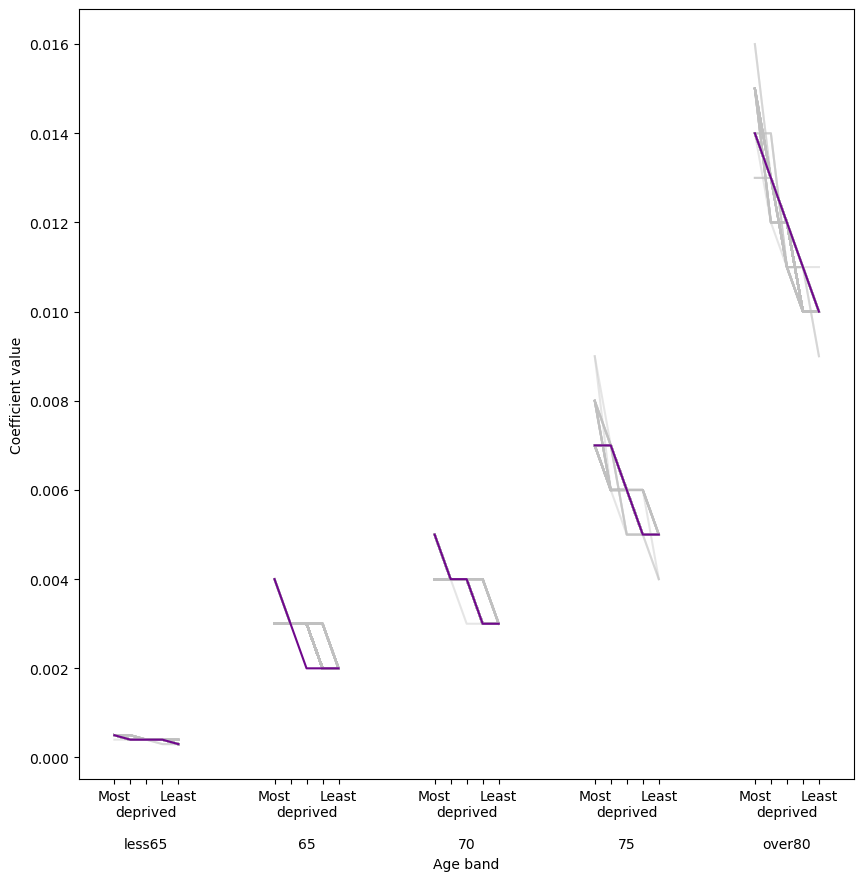

In [40]:
age_bands = ['less65', '65', '70', '75', 'over80']
x_offsets = np.arange(-0.2, 0.3, 0.1)
xticks_minor = np.concatenate([x_offsets + a for a in range(len(age_bands))])

qmin_labels = np.concatenate([['Most', '', '' + '\ndeprived\n\n' + age_band, '', 'Least'] for age_band in age_bands])

np.random.seed(2)
fig, ax = plt.subplots(figsize=(10, 10))

for results_dir in results_dirs:
    # Pick out coeffs:
    coeffs = df_best_gens.filter(df_best_gens['dir'] == results_dir)[coeff_names].to_numpy().flatten()
    if results_dir in df_best_gens_topr2['dir']:
        colour = np.random.rand(3,)
        zorder = 5
        alpha = 1.0
    else:
        colour = 'silver'
        zorder = 4
        alpha = 0.4
    # g = gen_attr(df_coeffs_init)

    offset = -0.2
    for c in range(5):
        # xs = np.arange(5) + offset
        # ys = g[c*5:(c*5)+5]
        xs = np.arange(-0.2, 0.3, 0.1) + c
        
        ys = np.array(coeffs)[np.arange(0, 25, 5) + c] #* np.array([coeffs_ssnap[c]] * 5)
        ax.plot(xs, ys, color=colour, zorder=zorder, alpha=alpha, label=(results_dir if c==0 else None))
        offset += 0.1

ax.set_xticks(xticks_minor)
ax.set_xticklabels(qmin_labels)
ax.set_xlabel('Age band')
ax.set_ylabel('Coefficient value')
plt.show()